In [67]:
import os
import glob
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix
import pynapple as nap
from spatial_manifolds.toroidal import *
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.data.binning import get_bin_config
from spatial_manifolds.mlencoding import *
from spatial_manifolds.circular_decoder import circular_decoder, cross_validate_decoder, cross_validate_decoder_time, circular_nanmean
from spatial_manifolds.data.curation import curate_clusters
from scipy.stats import zscore
from spatial_manifolds.util import gaussian_filter_nan
from spatial_manifolds.predictive_grid import compute_travel_projected, wrap_list
from spatial_manifolds.behaviour_plots import *
from spatial_manifolds.detect_grids import *
from spatial_manifolds.brainrender_helper import *
from spatial_manifolds.anaylsis_parameters import ngs_color, gc_color

import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
%matplotlib inline

fig_path   = '/Users/harryclark/Documents/spatial-manifolds/scripts/figures/figure_5_xgboost_medlat/'
os.makedirs(fig_path, exist_ok=True)
source_path = '/Users/harryclark/Downloads/COHORT12/'

cell_classifications = pd.read_csv('/Users/harryclark/Documents/spatial-manifolds/data/cell_classifications.csv')

# ── Medial / lateral threshold ────────────────────────────────────────────────
MEDLAT_THRESHOLD_UM = 3400   # cells with np.abs(SC_x) < threshold are 'medial'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [68]:
# ── Analysis configuration ────────────────────────────────────────────────────
CALCULATE_GC_TARGETS      = True
CALCULATE_NGS_TARGETS     = False
CACHE_ONLY                = False
FILTER_ENT_TARGETS_ONLY   = True   # True → restrict target cells to ENTm (MEC) only
# ─────────────────────────────────────────────────────────────────────────────


## XGBoost medial/lateral assay — GC / NGS predicted by NGS cells split by M-L position

### What this analysis does

For every session containing at least one grid cell (GC) and at least one non-grid spatial (NGS) cell, we fit XGBoost models to predict each **target cell's** (GC or NGS) firing rate in VR. Three covariate conditions are tested:

| `covariate_type` | Covariates |
|---|---|
| `pos` | Position alone (baseline) |
| `pos+ngs_medial` | Position + all NGS cells with `|SC_x| < 3400 µm` |
| `pos+ngs_lateral` | Position + all NGS cells with `|SC_x| ≥ 3400 µm` |

The medial/lateral boundary is fixed at **3400 µm** on the absolute mediolateral axis (`np.abs(SC_x)`).

Each target cell is also assigned its own `target_medlat` label. The `same_region` flag indicates whether the covariate NGS pool is from the same medial/lateral region as the target.

---

### Key metric — ΔpR²

$$\Delta pR^2 = pR^2(\text{pos} + \text{cells}) - pR^2(\text{pos})$$

ΔpR² isolates the variance explained **by the NGS cells alone**, above and beyond what position accounts for. A positive ΔpR² means that knowing the activity of NGS cells in a particular region improves prediction of the target cell's firing.

---

### Resulting dataframe — `results_df`

| Column | Description |
|---|---|
| `mouse` / `day` | Session identifier |
| `target_cluster_id` | Cluster ID of the target cell |
| `target_cell_type` | `GC` or `NG` |
| `target_medlat` | `medial` or `lateral` (target cell's own location) |
| `cov_region` | `medial` or `lateral` (NGS covariate pool region; `NaN` for baseline) |
| `n_ngs_cells` | Number of NGS cells used as covariates |
| `covariate_type` | `pos`, `pos+ngs_medial`, or `pos+ngs_lateral` |
| `pR2_cv` | Cross-validated Poisson pseudo-R² |
| `same_region` | Whether `cov_region == target_medlat` |

In [ ]:
# XGBoost model parameters
history_length = 1000  # ms
nfilters = int(history_length / time_bs)

xgb_history = MLencoding(
    tunemodel='xgboost',
    cov_history=True,
    spike_history=False,
    window=time_bs,
    n_filters=nfilters,
    max_time=history_length,
)

all_rows = []

cache_dir = '/Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_medlat_xgboost_cache'
os.makedirs(cache_dir, exist_ok=True)

# Sessions with at least 1 GC and at least 1 NGS cell
gc_sessions  = cell_classifications[cell_classifications['cell_type'] == 'GC'][['mouse', 'day']].drop_duplicates()
ngs_sessions = cell_classifications[cell_classifications['cell_type'] == 'NG'][['mouse', 'day']].drop_duplicates()
valid_sessions = gc_sessions.merge(ngs_sessions, on=['mouse', 'day'])
print(f"{len(valid_sessions)} sessions have at least 1 GC and 1 NGS cell.")

# ── Helper: assign medial / lateral label from SC_x ──────────────────────────
def assign_medlat(df, threshold=MEDLAT_THRESHOLD_UM):
    df = df.copy()
    df['SC_x'] = pd.to_numeric(df['SC_x'], errors='coerce')
    df['medlat'] = np.where(df['SC_x'].abs() < threshold, 'medial', 'lateral')
    return df

if CACHE_ONLY:
    print("CACHE_ONLY=True — loading cached files only, no new models will be fitted.")
    for _, sess_row in valid_sessions.iterrows():
        mouse_id = int(sess_row['mouse'])
        day_id   = int(sess_row['day'])
        _sess_targets = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'].isin(['GC', 'NG']))
        ]
        _loaded = 0
        for cid in _sess_targets['cluster_id']:
            cache_file = os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{int(cid)}_medlat.csv')
            if os.path.exists(cache_file):
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
                _loaded += 1
        if _loaded:
            print(f"  M{mouse_id} D{day_id:02d}: loaded {_loaded} cached target(s).")
else:
    _types_to_run = (
        (['GC'] if CALCULATE_GC_TARGETS  else []) +
        (['NG'] if CALCULATE_NGS_TARGETS else [])
    )
    if not _types_to_run:
        raise ValueError("Both CALCULATE_GC_TARGETS and CALCULATE_NGS_TARGETS are False — nothing to run.")
    print(f"Running for target types: {_types_to_run}")

    for _, sess_row in valid_sessions.iterrows():
        mouse_id = int(sess_row['mouse'])
        day_id   = int(sess_row['day'])

        # ── Session-level cache check ──────────────────────────────────────────
        _sess_targets_check = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'].isin(_types_to_run))
        ]
        _target_cache_files = {
            int(cid): os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{int(cid)}_medlat.csv')
            for cid in _sess_targets_check['cluster_id']
        }
        if len(_target_cache_files) > 0 and all(os.path.exists(f) for f in _target_cache_files.values()):
            for cache_file in _target_cache_files.values():
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
            print(f"M{mouse_id} D{day_id:02d}: all targets cached — skipping session load.")
            continue

        print(f"\n=== M{mouse_id} D{day_id:02d} ===")

        # ── Load session ───────────────────────────────────────────────────────
        try:
            tcs, tcs_time, _, last_ephys_bin, beh, clusters = compute_vr_tcs(
                mouse_id, day_id,
                apply_zscore=False, apply_guassian_filter=False,
                source_path=source_path,
            )
        except Exception as e:
            print(f"  Load failed: {e}")
            continue

        last_ephys_time_bin = clusters[clusters.index[0]].count(
            bin_size=time_bs, time_units='ms'
        ).index[-1]
        ep = nap.IntervalSet(start=0, end=last_ephys_time_bin, time_units='s')

        dt_in_time  = np.array(
            beh['travel'].bin_average(bin_size=time_bs, time_units='ms', ep=ep)
            - ((beh['trial_number'][0] - 1) * tl)
        )
        pos_in_time = dt_in_time % tl
        if np.any(np.isnan(pos_in_time)):
            pos_in_time = pd.Series(dt_in_time).ffill().bfill().values % tl

        # ── Session cell tables with medlat labels ─────────────────────────────
        sess_gcs = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'] == 'GC')
        ].copy()
        sess_ngs = cell_classifications[
            (cell_classifications['mouse'] == mouse_id) &
            (cell_classifications['day']   == day_id) &
            (cell_classifications['cell_type'] == 'NG')
        ].copy()

        sess_gcs['cluster_id'] = sess_gcs['cluster_id'].astype(int)
        sess_ngs['cluster_id'] = sess_ngs['cluster_id'].astype(int)
        sess_gcs = assign_medlat(sess_gcs)
        sess_ngs = assign_medlat(sess_ngs)

        # Group NGS cells by medlat region — keep only groups with ≥1 cell in tcs_time
        ngs_by_region = {
            region: grp['cluster_id'].values.astype(int)
            for region, grp in sess_ngs.groupby('medlat')
            if any(c in tcs_time for c in grp['cluster_id'].astype(int))
        }

        if not ngs_by_region:
            print(f"  No NGS cells in tcs_time for any region — skipping.")
            continue

        print(f"  GCs: {len(sess_gcs)}  NGS: {len(sess_ngs)}  |  NGS regions: { {r: len(v) for r,v in ngs_by_region.items()} }")

        # ── Loop over target cells ─────────────────────────────────────────────
        sess_targets = pd.concat([sess_gcs, sess_ngs], ignore_index=True)
        sess_targets = sess_targets[sess_targets['cell_type'].isin(_types_to_run)]

        for _, target_row in sess_targets.iterrows():
            target_id       = int(target_row['cluster_id'])
            target_type     = str(target_row['cell_type'])
            target_ml       = str(target_row['medlat'])
            target_sc_x_abs = float(np.abs(pd.to_numeric(target_row['SC_x'], errors='coerce')))

            cache_file = os.path.join(cache_dir, f'M{mouse_id}_D{day_id:02d}_C{target_id}_medlat.csv')
            if os.path.exists(cache_file):
                all_rows.extend(pd.read_csv(cache_file).to_dict('records'))
                continue

            if target_id not in tcs_time:
                continue

            y   = np.array(tcs_time[target_id])
            T   = len(y)
            pos = pos_in_time[:T]
            if len(pos) < T:
                pos = np.pad(pos, (0, T - len(pos)), mode='edge')

            target_rows = []

            # ── Baseline: position only ────────────────────────────────────────
            _, pR2_cv = xgb_history.fit_cv(pos[:, None], y, verbose=0, continuous_folds=True)
            target_rows.append(dict(
                mouse=mouse_id, day=day_id,
                target_cluster_id=target_id,
                target_cell_type=target_type,
                target_medlat=target_ml,
                target_SC_x_abs=target_sc_x_abs,
                cov_region=np.nan,
                n_ngs_cells=np.nan,
                covariate_type='pos',
                pR2_cv=float(np.nanmean(pR2_cv)),
                same_region=np.nan,
            ))

            # ── One model per medlat region ────────────────────────────────────
            for region, ngs_cids in ngs_by_region.items():
                valid_ngs = [c for c in ngs_cids if c in tcs_time and c != target_id]
                if not valid_ngs:
                    continue

                ngs_mat = np.vstack([
                    np.pad(
                        np.array(tcs_time[c])[:T],
                        (0, max(0, T - len(np.array(tcs_time[c])[:T]))),
                        mode='constant'
                    )
                    for c in valid_ngs
                ]).T  # shape (T, n_ngs)

                x = np.column_stack([pos, ngs_mat])
                _, pR2_cv = xgb_history.fit_cv(x, y, verbose=0, continuous_folds=True)
                target_rows.append(dict(
                    mouse=mouse_id, day=day_id,
                    target_cluster_id=target_id,
                    target_cell_type=target_type,
                    target_medlat=target_ml,
                    target_SC_x_abs=target_sc_x_abs,
                    cov_region=region,
                    n_ngs_cells=len(valid_ngs),
                    covariate_type=f'pos+ngs_{region}',
                    pR2_cv=float(np.nanmean(pR2_cv)),
                    same_region=(region == target_ml),
                ))

            pd.DataFrame(target_rows).to_csv(cache_file, index=False)
            all_rows.extend(target_rows)
            print(f"    {target_type} {target_id} ({target_ml}): done.")

results_df = pd.DataFrame(all_rows)

# ── Join brain_region from cell_classifications via mouse / day / target_cluster_id ──
_region_lookup = (
    cell_classifications[['mouse', 'day', 'cluster_id', 'brain_region']]
    .rename(columns={'cluster_id': 'target_cluster_id'})
    .drop_duplicates(subset=['mouse', 'day', 'target_cluster_id'])
)
results_df = results_df.merge(_region_lookup, on=['mouse', 'day', 'target_cluster_id'], how='left')

# ── Optional ENTm filter ───────────────────────────────────────────────────────
if FILTER_ENT_TARGETS_ONLY:
    results_df = results_df[
        results_df['brain_region'].str.contains('ENTm', na=False)
    ].reset_index(drop=True)
    print(f"FILTER_ENT_TARGETS_ONLY=True — {len(results_df)} rows after ENTm filter.")

print(f"\nTotal rows collected: {len(results_df)}")
print(f"covariate_type counts:\n{results_df['covariate_type'].value_counts()}")

results_df.head(10)

In [70]:
save_path = '/Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_medlat_xgboost.csv'
results_df.to_csv(save_path, index=False)
print(f"Saved {len(results_df)} rows → {save_path}")

Saved 1481 rows → /Users/harryclark/Documents/spatial-manifolds/data/gc_ngs_medlat_xgboost.csv


In [71]:
# ── Build delta_df: ΔpR² = pR²(pos+ngs_region) − pR²(pos) ───────────────────
_pos_rows = (
    results_df[results_df['covariate_type'] == 'pos']
    [['mouse', 'day', 'target_cluster_id', 'target_cell_type', 'target_medlat', 'pR2_cv']]
    .rename(columns={'pR2_cv': 'pR2_pos'})
)

_ngs_rows = (
    results_df[results_df['covariate_type'].isin(['pos+ngs_medial', 'pos+ngs_lateral'])]
    [['mouse', 'day', 'target_cluster_id', 'target_cell_type', 'target_medlat',
      'cov_region', 'n_ngs_cells', 'pR2_cv', 'same_region']]
    .rename(columns={'pR2_cv': 'pR2_pos_ngs'})
)

delta_df = _ngs_rows.merge(
    _pos_rows,
    on=['mouse', 'day', 'target_cluster_id', 'target_cell_type', 'target_medlat'],
    how='inner',
)
delta_df['delta_pR2'] = delta_df['pR2_pos_ngs'] - delta_df['pR2_pos']

print(f"delta_df: {len(delta_df)} rows")
for ttype in ['GC', 'NG']:
    for region in ['medial', 'lateral']:
        sub = delta_df[
            (delta_df['target_cell_type'] == ttype) &
            (delta_df['cov_region'] == region)
        ]['delta_pR2']
        print(f"  {ttype} cov={region}  ΔpR² mean={sub.mean():.4f}  median={sub.median():.4f}  n={len(sub)}")
delta_df.head()

delta_df: 864 rows
  GC cov=medial  ΔpR² mean=0.0892  median=0.0528  n=492
  GC cov=lateral  ΔpR² mean=0.0436  median=0.0287  n=372
  NG cov=medial  ΔpR² mean=nan  median=nan  n=0
  NG cov=lateral  ΔpR² mean=nan  median=nan  n=0


,mouse,day,target_cluster_id,target_cell_type,target_medlat,cov_region,n_ngs_cells,pR2_pos_ngs,same_region,pR2_pos,delta_pR2
0,20,14,34,GC,medial,lateral,75.0,0.052387,False,0.027396,0.024991
1,20,14,34,GC,medial,medial,34.0,0.057976,True,0.027396,0.030580
2,20,14,103,GC,medial,lateral,75.0,0.065243,False,0.016471,0.048772
3,20,14,103,GC,medial,medial,34.0,0.070144,True,0.016471,0.053672
4,20,14,400,GC,lateral,lateral,75.0,0.085118,True,0.025056,0.060062


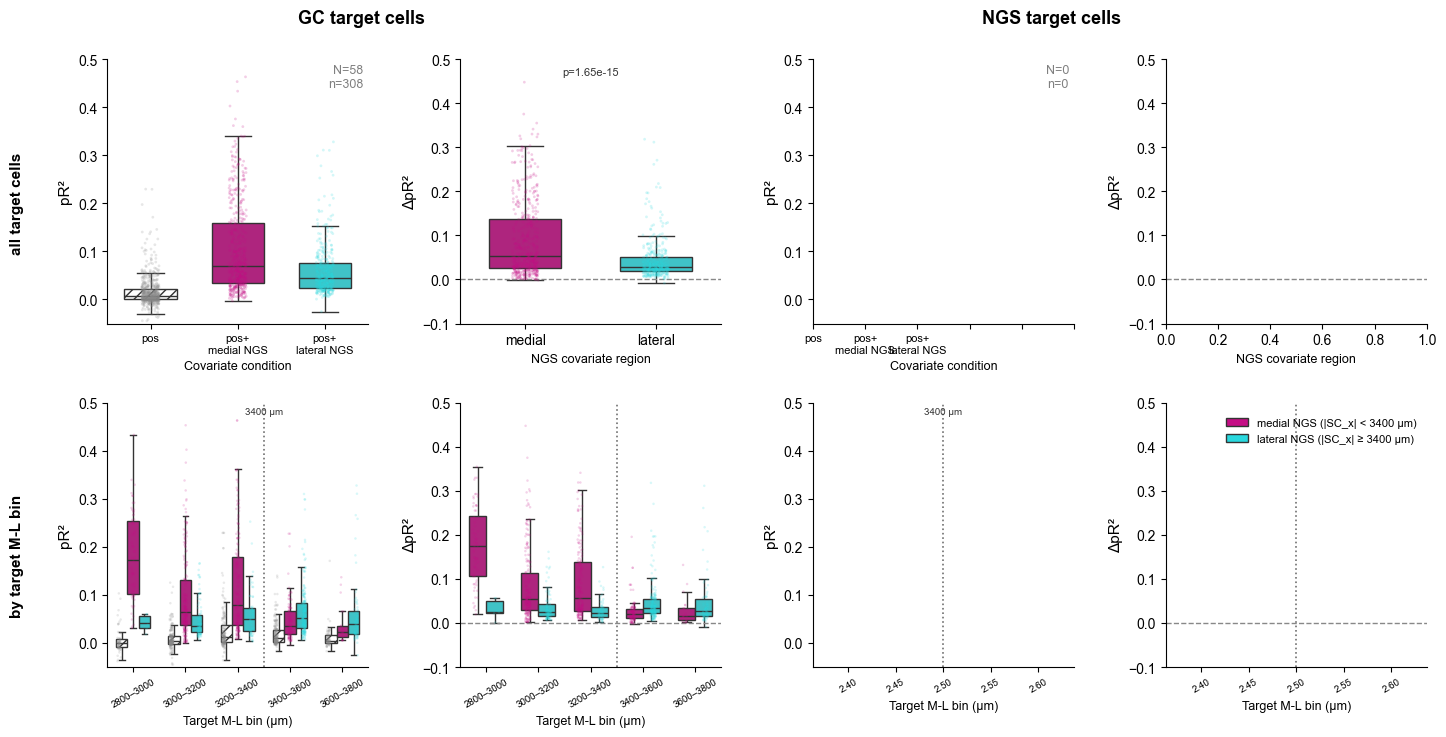

In [72]:
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats

# ── Figure layout ─────────────────────────────────────────────────────────────
# 2 rows × 4 columns:
#   Row 0: raw pR²  (medial/lateral covariate)  |  ΔpR² comparison  — for GC and NG
#   Row 1: same but split by target cell's own M-L bin
#
# Col 0: GC — raw pR²
# Col 1: GC — ΔpR²
# Col 2: NG — raw pR²
# Col 3: NG — ΔpR²

MEDLAT_THRESHOLD_UM = 3400
region_order  = ['medial', 'lateral']
region_colors = {'medial': "#C50E85", 'lateral': "#29d8de"}

target_types = ['GC', 'NG']
_type_color  = {'GC': gc_color, 'NG': ngs_color}
_type_label  = {'GC': 'GC',     'NG': 'NGS'}

cond_order   = ['pos', 'pos+ngs_medial', 'pos+ngs_lateral']
cond_palette = {
    'pos':             'white',
    'pos+ngs_medial':  region_colors['medial'],
    'pos+ngs_lateral': region_colors['lateral'],
}
cond_strip = {
    'pos':             '#888888',
    'pos+ngs_medial':  region_colors['medial'],
    'pos+ngs_lateral': region_colors['lateral'],
}

# M-L bins for the bottom row
bin_edges  = np.arange(2800, 4000, 200)
bin_labels = [f'{int(bin_edges[i])}–{int(bin_edges[i+1])}' for i in range(len(bin_edges)-1)]

_locs = (
    cell_classifications[['mouse', 'day', 'cluster_id', 'SC_x', 'cell_type']]
    .rename(columns={'cluster_id': 'target_cluster_id'})
    .copy()
)
_locs['SC_x'] = pd.to_numeric(_locs['SC_x'], errors='coerce')
_locs['SC_x_bin'] = pd.cut(_locs['SC_x'].abs(), bins=bin_edges, labels=bin_labels, right=True)
_locs = _locs.dropna(subset=['SC_x_bin'])
_locs['SC_x_bin'] = pd.Categorical(_locs['SC_x_bin'].astype(str), categories=bin_labels, ordered=True)

fig, axes = plt.subplots(
    2, 4, figsize=(15, 8),
    gridspec_kw={'hspace': 0.30, 'wspace': 0.35},
    sharey=False,
)
fig.subplots_adjust(left=0.10, right=0.98, top=0.90, bottom=0.14)

for col, _ttype in enumerate(target_types):
    _col = _type_color[_ttype]
    _lbl = _type_label[_ttype]

    # ── Prepare per-cell long-form table ──────────────────────────────────────
    _sub = results_df[results_df['target_cell_type'] == _ttype].copy()

    # Join M-L bin
    _sub_bins = _sub.merge(
        _locs[['mouse', 'day', 'target_cluster_id', 'SC_x_bin']],
        on=['mouse', 'day', 'target_cluster_id'], how='inner'
    )

    # ── Row 0, left: raw pR² by covariate condition ───────────────────────────
    ax = axes[0, col * 2]
    sns.boxplot(
        data=_sub, x='covariate_type', y='pR2_cv',
        order=cond_order, palette=cond_palette,
        width=0.6, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=_sub, x='covariate_type', y='pR2_cv',
        order=cond_order, palette=cond_strip,
        alpha=0.20, jitter=True, size=2.0, ax=ax, legend=False,
    )
    # Hatch the pos baseline box
    for patch in ax.patches[:1]:
        patch.set_hatch('///'); patch.set_edgecolor('#333333')
    ax.set_xlabel('Covariate condition', fontsize=9)
    ax.set_ylabel('pR²', fontsize=11)
    ax.set_ylim(-0.05, 0.5)
    ax.set_xticklabels(['pos', 'pos+\nmedial NGS', 'pos+\nlateral NGS'], fontsize=8)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax.get_legend(): ax.get_legend().remove()
    N = _sub['mouse'].astype(str) + '_' + _sub['day'].astype(str)
    n = _sub['target_cluster_id'].nunique()
    ax.text(0.98, 0.98, f'N={N.nunique()}\nn={n}',
            ha='right', va='top', color='grey', fontsize=9, transform=ax.transAxes)

    # ── Row 0, right: ΔpR² medial vs lateral covariate ───────────────────────
    ax = axes[0, col * 2 + 1]
    _delta_sub = delta_df[delta_df['target_cell_type'] == _ttype].copy()
    sns.boxplot(
        data=_delta_sub, x='cov_region', y='delta_pR2',
        order=region_order,
        palette=region_colors,
        width=0.55, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=_delta_sub, x='cov_region', y='delta_pR2',
        order=region_order,
        palette=region_colors,
        alpha=0.20, jitter=True, size=2.0, ax=ax,
    )
    # Statistical annotation: Mann-Whitney U
    _med = _delta_sub[_delta_sub['cov_region'] == 'medial']['delta_pR2'].dropna()
    _lat = _delta_sub[_delta_sub['cov_region'] == 'lateral']['delta_pR2'].dropna()
    if len(_med) > 1 and len(_lat) > 1:
        _u, _p = stats.mannwhitneyu(_med, _lat, alternative='two-sided')
        _pstr = f'p={_p:.2e}' if _p < 0.001 else f'p={_p:.3f}'
        ax.text(0.5, 0.97, _pstr, ha='center', va='top', fontsize=8,
                color='#333', transform=ax.transAxes)
    ax.axhline(0, color='#888', lw=1, ls='--')
    ax.set_xlabel('NGS covariate region', fontsize=9)
    ax.set_ylabel('ΔpR²', fontsize=11)
    ax.set_ylim(-0.10, 0.50)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

    # ── Row 1, left: raw pR² by M-L bin of target cell ───────────────────────
    ax = axes[1, col * 2]
    _sub_bins_long = _sub_bins.copy()
    sns.boxplot(
        data=_sub_bins_long, x='SC_x_bin', y='pR2_cv',
        hue='covariate_type', hue_order=cond_order, order=bin_labels,
        palette=cond_palette,
        width=0.65, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=_sub_bins_long, x='SC_x_bin', y='pR2_cv',
        hue='covariate_type', hue_order=cond_order, order=bin_labels,
        palette=cond_strip,
        alpha=0.18, jitter=True, size=1.8, dodge=True, ax=ax, legend=False,
    )
    # Hatch pos boxes
    for patch in ax.patches[:len(bin_labels)]:
        patch.set_hatch('///'); patch.set_edgecolor('#333333')
    # Vertical line at medial/lateral boundary
    _boundary_idx = next(
        (i for i, lbl in enumerate(bin_labels) if int(lbl.split('–')[1]) > MEDLAT_THRESHOLD_UM), None
    )
    if _boundary_idx is not None:
        ax.axvline(_boundary_idx - 0.5, color='#333', lw=1.2, ls=':', alpha=0.7)
        ax.text(_boundary_idx - 0.5, 0.49, '3400 µm', fontsize=7, color='#333',
                ha='center', va='top')
    ax.set_xlabel('Target M-L bin (µm)', fontsize=9)
    ax.set_ylabel('pR²', fontsize=11)
    ax.set_ylim(-0.05, 0.50)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax.get_legend(): ax.get_legend().remove()

    # ── Row 1, right: ΔpR² by M-L bin, with medial vs lateral hue ───────────
    ax = axes[1, col * 2 + 1]
    _delta_bins = delta_df[delta_df['target_cell_type'] == _ttype].merge(
        _locs[['mouse', 'day', 'target_cluster_id', 'SC_x_bin']],
        on=['mouse', 'day', 'target_cluster_id'], how='inner'
    )
    sns.boxplot(
        data=_delta_bins, x='SC_x_bin', y='delta_pR2',
        hue='cov_region', hue_order=region_order, order=bin_labels,
        palette=region_colors,
        width=0.65, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=_delta_bins, x='SC_x_bin', y='delta_pR2',
        hue='cov_region', hue_order=region_order, order=bin_labels,
        palette=region_colors,
        alpha=0.18, jitter=True, size=1.8, dodge=True, ax=ax, legend=False,
    )
    if _boundary_idx is not None:
        ax.axvline(_boundary_idx - 0.5, color='#333', lw=1.2, ls=':', alpha=0.7)
    ax.axhline(0, color='#888', lw=1, ls='--')
    ax.set_xlabel('Target M-L bin (µm)', fontsize=9)
    ax.set_ylabel('ΔpR²', fontsize=11)
    ax.set_ylim(-0.10, 0.50)
    ax.tick_params(axis='x', labelsize=7, rotation=30)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    # Legend on last column only
    if col == 1:
        legend_elements = [
            Patch(facecolor=region_colors['medial'],  edgecolor='#333', label='medial NGS (|SC_x| < 3400 µm)'),
            Patch(facecolor=region_colors['lateral'], edgecolor='#333', label='lateral NGS (|SC_x| ≥ 3400 µm)'),
        ]
        ax.legend(handles=legend_elements, fontsize=8, frameon=False,
                  loc='upper right', bbox_to_anchor=(1.0, 0.98))
    else:
        if ax.get_legend(): ax.get_legend().remove()

# ── Column and row titles ─────────────────────────────────────────────────────
fig.text(0.27, 0.94, 'GC target cells',  ha='center', va='bottom', fontsize=13, fontweight='bold')
fig.text(0.73, 0.94, 'NGS target cells', ha='center', va='bottom', fontsize=13, fontweight='bold')
fig.text(0.04, 0.72, 'all target cells',         va='center', ha='center', rotation=90, fontsize=11, fontweight='bold')
fig.text(0.04, 0.28, 'by target M-L bin', va='center', ha='center', rotation=90, fontsize=11, fontweight='bold')

plt.savefig(fig_path + 'figure_medlat_summary.pdf', dpi=300, bbox_inches='tight')
plt.show()

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pR2_cv   
No. Observations: 2312    Method:             REML     
No. Groups:       8       Scale:              0.0008   
Min. group size:  1       Log-Likelihood:     4848.0724
Max. group size:  674     Converged:          Yes      
Mean group size:  289.0                                
-------------------------------------------------------
               Coef. Std.Err.   z   P>|z| [0.025 0.975]
-------------------------------------------------------
Intercept      0.001    0.022 0.054 0.957 -0.041  0.043
sc_x_mm        0.005    0.006 0.763 0.446 -0.008  0.017
session Var    0.000    0.002                          

         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta_pR2
No. Observations: 1962    Method:             REML     
No. Groups:       8       Scale:              0.0025   
Min. group size:  1       Log-Likelihood:     3025.2106
Max. grou

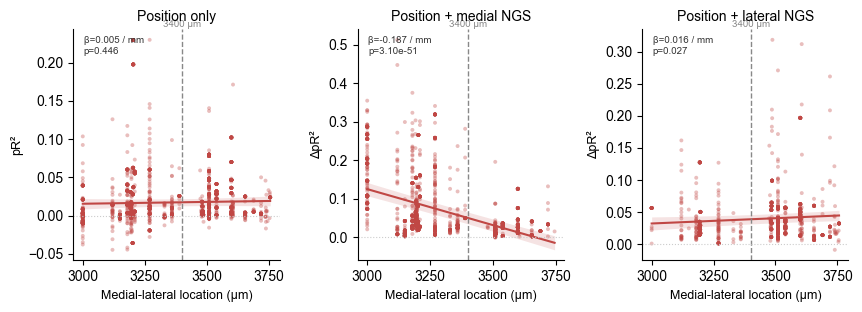

In [81]:
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D

# ── Join SC_x (drop first to avoid suffix conflicts) ──────────────────────────
_sc_x = (
    cell_classifications[['mouse', 'day', 'cluster_id', 'SC_x']]
    .rename(columns={'cluster_id': 'target_cluster_id'})
    .copy()
)
_sc_x['SC_x'] = pd.to_numeric(_sc_x['SC_x'], errors='coerce')
_sc_x['target_SC_x_abs'] = _sc_x['SC_x'].abs()
_sc_x = _sc_x[['mouse', 'day', 'target_cluster_id', 'target_SC_x_abs']]

for _df in [results_df, delta_df]:
    if 'target_SC_x_abs' in _df.columns:
        _df.drop(columns=['target_SC_x_abs'], inplace=True)

results_df = results_df.merge(_sc_x, on=['mouse', 'day', 'target_cluster_id'], how='left')
delta_df   = delta_df.merge(_sc_x,   on=['mouse', 'day', 'target_cluster_id'], how='left')

# ── LME fit helper ────────────────────────────────────────────────────────────
def _fit_lme(df, outcome):
    _d = df[[outcome, 'target_SC_x_abs', 'mouse', 'day']].dropna().copy()
    _d['sc_x_mm'] = _d['target_SC_x_abs'] / 1000.0
    _d['session'] = _d['mouse'].astype(str) + '_' + _d['day'].astype(str)

    md  = smf.mixedlm(
        f"{outcome} ~ sc_x_mm",
        data=_d,
        groups=_d['mouse'],
        vc_formula={'session': '0 + C(session)'}
    )
    mdf = md.fit(reml=True, method='lbfgs')
    print(mdf.summary())

    intercept = mdf.fe_params['Intercept']
    slope_mm  = mdf.fe_params['sc_x_mm']
    pval      = mdf.pvalues['sc_x_mm']

    x_mm  = np.linspace(_d['sc_x_mm'].min(), _d['sc_x_mm'].max(), 200)
    y_fit = intercept + slope_mm * x_mm

    # SE of fixed-effects prediction from covariance matrix of fixed effects
    cov_fe = mdf.cov_params().loc[
        ['Intercept', 'sc_x_mm'], ['Intercept', 'sc_x_mm']
    ].values
    X_pred = np.column_stack([np.ones(len(x_mm)), x_mm])
    se_fit = np.sqrt(np.einsum('ij,jk,ik->i', X_pred, cov_fe, X_pred))

    return x_mm * 1000, y_fit, se_fit, pval, slope_mm

# ── Plot helper ───────────────────────────────────────────────────────────────
region_colors = {'medial': '#c04744', 'lateral': '#c04744'}

def _scatter_with_lme(ax, x, y, df, outcome, ylabel, title):
    point_colors = np.where(x < MEDLAT_THRESHOLD_UM,
                            region_colors['medial'],
                            region_colors['lateral'])
    ax.scatter(x, y, c=point_colors, s=8, alpha=0.35, linewidths=0)

    x_fit, y_fit, se_fit, pval, slope = _fit_lme(df, outcome)
    ax.plot(x_fit, y_fit, color='#c04744', lw=1.5)
    ax.fill_between(x_fit,
                    y_fit - 1.96 * se_fit,
                    y_fit + 1.96 * se_fit,
                    color='#c04744', alpha=0.15, linewidth=0)

    pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
    ax.text(0.05, 0.97, f'β={slope:.3f} / mm\n{pstr}',
            transform=ax.transAxes, fontsize=7, va='top', color='#333333')

    ax.axvline(MEDLAT_THRESHOLD_UM, color='#888888', lw=1, ls='--')
    ax.axhline(0, color='#cccccc', lw=0.8, ls=':')
    ax.set_xlabel('Medial-lateral location (µm)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.text(MEDLAT_THRESHOLD_UM, ax.get_ylim()[1], '3400 µm',
            fontsize=7, color='#888888', ha='center', va='bottom')

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 3))
fig.subplots_adjust(wspace=0.38)

_pos = results_df[
    (results_df['target_cell_type'] == 'GC') &
    (results_df['covariate_type']   == 'pos')
].dropna(subset=['target_SC_x_abs', 'pR2_cv'])

_scatter_with_lme(axes[0], _pos['target_SC_x_abs'].values, _pos['pR2_cv'].values,
                  _pos, 'pR2_cv', ylabel='pR²', title='Position only')

_med = delta_df[
    (delta_df['target_cell_type'] == 'GC') &
    (delta_df['cov_region']       == 'medial')
].dropna(subset=['target_SC_x_abs', 'delta_pR2'])

_scatter_with_lme(axes[1], _med['target_SC_x_abs'].values, _med['delta_pR2'].values,
                  _med, 'delta_pR2', ylabel='ΔpR²', title='Position + medial NGS')

_lat = delta_df[
    (delta_df['target_cell_type'] == 'GC') &
    (delta_df['cov_region']       == 'lateral')
].dropna(subset=['target_SC_x_abs', 'delta_pR2'])

_scatter_with_lme(axes[2], _lat['target_SC_x_abs'].values, _lat['delta_pR2'].values,
                  _lat, 'delta_pR2', ylabel='ΔpR²', title='Position + lateral NGS')

plt.savefig(fig_path + 'figure_gc_scx_pr2.pdf', dpi=300, bbox_inches='tight')
plt.show()


         Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pR2_cv   
No. Observations: 598     Method:             REML     
No. Groups:       8       Scale:              0.0008   
Min. group size:  1       Log-Likelihood:     1253.2284
Max. group size:  164     Converged:          Yes      
Mean group size:  74.8                                 
--------------------------------------------------------
           Coef.  Std.Err.    z    P>|z|  [0.025  0.975]
--------------------------------------------------------
Intercept  0.006     0.021  0.292  0.770  -0.034   0.046
sc_x_mm    0.003     0.006  0.527  0.598  -0.009   0.015
Group Var  0.000     0.003                              

        Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: pR2_cv  
No. Observations: 474     Method:             REML    
No. Groups:       8       Scale:              0.0063  
Min. group size:  1       Log-Likelihood:     514.4757
Max. gro

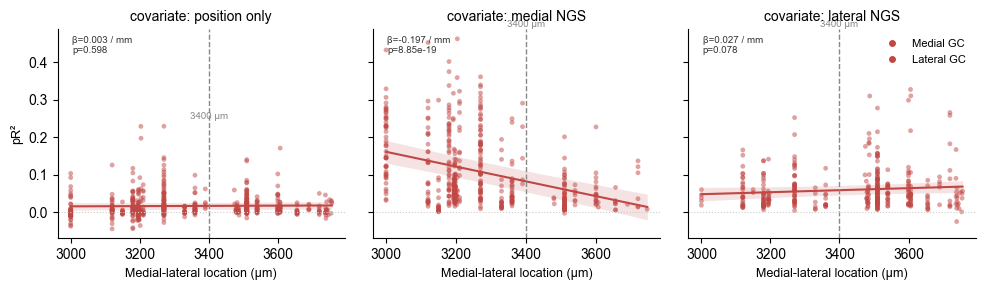

In [80]:
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D

# ── Cell-average pR² per cell (one value per cell, averaged across days) ──────
# This is the recommended approach since SC_x is a cell-level predictor
def _cell_avg(covariate_type):
    return (
        results_df[
            (results_df['target_cell_type'] == 'GC') &
            (results_df['covariate_type']   == covariate_type)
        ]
        .dropna(subset=['target_SC_x_abs', 'pR2_cv'])
        .groupby(['mouse', 'target_cluster_id', 'target_SC_x_abs'])
        ['pR2_cv'].mean()
        .reset_index()
    )

_avg_pos = _cell_avg('pos')
_avg_med = _cell_avg('pos+ngs_medial')
_avg_lat = _cell_avg('pos+ngs_lateral')

# ── LME fit (cell-level: mouse random intercept only) ─────────────────────────
def _fit_lme_cell(df, outcome='pR2_cv'):
    _d = df[[outcome, 'target_SC_x_abs', 'mouse']].dropna().copy()
    _d['sc_x_mm'] = _d['target_SC_x_abs'] / 1000.0

    md  = smf.mixedlm(f"{outcome} ~ sc_x_mm", data=_d, groups=_d['mouse'])
    mdf = md.fit(reml=True, method='lbfgs')
    print(mdf.summary())

    intercept = mdf.fe_params['Intercept']
    slope_mm  = mdf.fe_params['sc_x_mm']
    pval      = mdf.pvalues['sc_x_mm']

    x_mm  = np.linspace(_d['sc_x_mm'].min(), _d['sc_x_mm'].max(), 200)
    y_fit = intercept + slope_mm * x_mm

    cov_fe = mdf.cov_params().loc[
        ['Intercept', 'sc_x_mm'], ['Intercept', 'sc_x_mm']
    ].values
    X_pred = np.column_stack([np.ones(len(x_mm)), x_mm])
    se_fit = np.sqrt(np.einsum('ij,jk,ik->i', X_pred, cov_fe, X_pred))

    return x_mm * 1000, y_fit, se_fit, pval, slope_mm

# ── Plot helper ───────────────────────────────────────────────────────────────
region_colors = {'medial': '#c04744', 'lateral': '#c04744'}

def _scatter_lme_cell(ax, df, ylabel, title):
    x = df['target_SC_x_abs'].values
    y = df['pR2_cv'].values

    point_colors = np.where(x < MEDLAT_THRESHOLD_UM,
                            region_colors['medial'],
                            region_colors['lateral'])
    ax.scatter(x, y, c=point_colors, s=12, alpha=0.5, linewidths=0)

    x_fit, y_fit, se_fit, pval, slope = _fit_lme_cell(df)
    ax.plot(x_fit, y_fit, color='#c04744', lw=1.5)
    ax.fill_between(x_fit,
                    y_fit - 1.96 * se_fit,
                    y_fit + 1.96 * se_fit,
                    color='#c04744', alpha=0.15, linewidth=0)

    pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
    ax.text(0.05, 0.97, f'β={slope:.3f} / mm\n{pstr}',
            transform=ax.transAxes, fontsize=7, va='top', color='#333333')

    ax.axvline(MEDLAT_THRESHOLD_UM, color='#888888', lw=1, ls='--')
    ax.axhline(0, color='#cccccc', lw=0.8, ls=':')
    ax.text(MEDLAT_THRESHOLD_UM, ax.get_ylim()[1], '3400 µm',
            fontsize=7, color='#888888', ha='center', va='bottom')
    ax.set_xlabel('Medial-lateral location (µm)', fontsize=9)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(10, 3), sharey=True)
fig.subplots_adjust(wspace=0.38)

_scatter_lme_cell(axes[0], _avg_pos, ylabel='pR²', title='covariate: position only')
_scatter_lme_cell(axes[1], _avg_med, ylabel='', title='covariate: medial NGS')
_scatter_lme_cell(axes[2], _avg_lat, ylabel='', title='covariate: lateral NGS')

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor=region_colors['medial'],
           markersize=6, label='Medial GC'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor=region_colors['lateral'],
           markersize=6, label='Lateral GC'),
]
axes[2].legend(handles=legend_elements, fontsize=8, frameon=False, loc='upper right')
plt.tight_layout()
plt.savefig(fig_path + 'figure_gc_medlat_pr2.pdf', dpi=300, bbox_inches='tight')
plt.show()


In [75]:
cell_classifications[(cell_classifications['cell_type'] == 'GC') & (cell_classifications['brain_region'].str.contains('ENTm'))]
GCS_SC_x_abs = np.abs(cell_classifications[(cell_classifications['cell_type'] == 'GC') & (cell_classifications['brain_region'].str.contains('ENTm'))]['SC_x'].values)
min(GCS_SC_x_abs)
max(GCS_SC_x_abs)


np.float64(3756.630588304794)

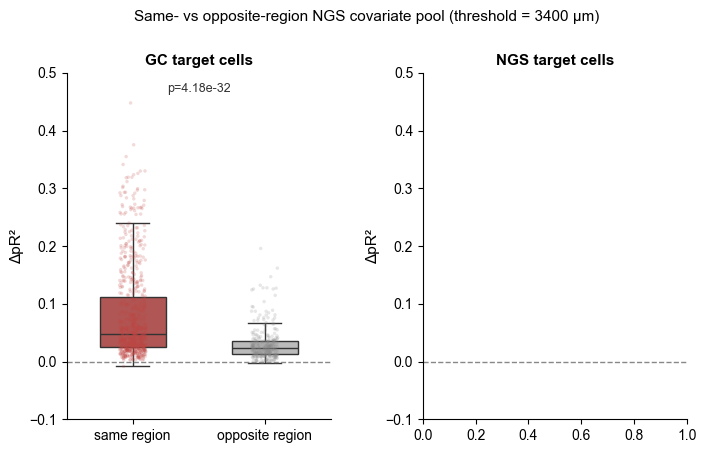

In [76]:
# ── Same-region vs cross-region ΔpR² comparison ──────────────────────────────
# Does the covariate pool from the same medial/lateral region as the target
# provide better prediction than the pool from the opposite region?

fig, axes = plt.subplots(1, 2, figsize=(8, 4.5))
fig.subplots_adjust(wspace=0.35)

for ax, _ttype in zip(axes, ['GC', 'NG']):
    _d = delta_df[delta_df['target_cell_type'] == _ttype].copy()
    _d['region_label'] = np.where(_d['same_region'], 'same region', 'opposite region')

    sns.boxplot(
        data=_d, x='region_label', y='delta_pR2',
        order=['same region', 'opposite region'],
        palette={'same region': _type_color[_ttype], 'opposite region': '#bbbbbb'},
        width=0.5, fliersize=0, linecolor='#333333', ax=ax,
    )
    sns.stripplot(
        data=_d, x='region_label', y='delta_pR2',
        order=['same region', 'opposite region'],
        palette={'same region': _type_color[_ttype], 'opposite region': '#888888'},
        alpha=0.20, jitter=True, size=2.5, ax=ax,
    )

    _same = _d[_d['same_region'] == True]['delta_pR2'].dropna()
    _opp  = _d[_d['same_region'] == False]['delta_pR2'].dropna()
    if len(_same) > 1 and len(_opp) > 1:
        _u, _p = stats.mannwhitneyu(_same, _opp, alternative='two-sided')
        _pstr = f'p={_p:.2e}' if _p < 0.001 else f'p={_p:.3f}'
        ax.text(0.5, 0.97, _pstr, ha='center', va='top', fontsize=9,
                color='#333', transform=ax.transAxes)

    ax.axhline(0, color='#888', lw=1, ls='--')
    ax.set_xlabel('')
    ax.set_ylabel('ΔpR²', fontsize=11)
    ax.set_title(f'{_type_label[_ttype]} target cells', fontsize=11, fontweight='bold')
    ax.set_ylim(-0.10, 0.50)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.suptitle('Same- vs opposite-region NGS covariate pool (threshold = 3400 µm)',
             fontsize=11, y=1.02)
plt.savefig(fig_path + 'figure_medlat_same_vs_opposite.pdf', dpi=300, bbox_inches='tight')
plt.show()

                           Mixed Linear Model Regression Results
Model:                         MixedLM            Dependent Variable:            n_ngs_cells
No. Observations:              80                 Method:                        REML       
No. Groups:                    8                  Scale:                         966.4194   
Min. group size:               1                  Log-Likelihood:                -414.2336  
Max. group size:               18                 Converged:                     Yes        
Mean group size:               10.0                                                         
--------------------------------------------------------------------------------------------
                                               Coef.   Std.Err.   z    P>|z|  [0.025  0.975]
--------------------------------------------------------------------------------------------
Intercept                                       91.146    7.546 12.079 0.000  76.357 105.935
C(cov

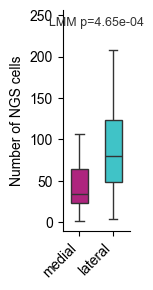

In [77]:
import statsmodels.formula.api as smf

# n_ngs_cells is session-level — deduplicate before fitting
_n = (
    delta_df[delta_df['target_cell_type'] == 'GC']
    .dropna(subset=['n_ngs_cells', 'cov_region'])
    [['mouse', 'day', 'cov_region', 'n_ngs_cells']]
    .drop_duplicates()
    .copy()
)
_n['session'] = _n['mouse'].astype(str) + '_' + _n['day'].astype(str)

# ── LMM ───────────────────────────────────────────────────────────────────────
md  = smf.mixedlm(
    "n_ngs_cells ~ C(cov_region, Treatment('lateral'))",
    data=_n,
    groups=_n['mouse'],
    vc_formula={'session': '0 + C(session)'}
)
mdf = md.fit(reml=True, method='lbfgs')
print(mdf.summary())

intercept = mdf.fe_params['Intercept']
coef_med  = mdf.fe_params["C(cov_region, Treatment('lateral'))[T.medial]"]
pval      = mdf.pvalues["C(cov_region, Treatment('lateral'))[T.medial]"]
se_med    = mdf.bse["C(cov_region, Treatment('lateral'))[T.medial]"]

est = {'lateral': intercept, 'medial': intercept + coef_med}
ci  = {'lateral': 1.96 * mdf.bse['Intercept'],
       'medial':  1.96 * np.sqrt(mdf.bse['Intercept']**2 + se_med**2)}

# ── Plot ──────────────────────────────────────────────────────────────────────
region_order  = ['medial', 'lateral']
region_colors = {'medial': '#C50E85', 'lateral': '#29d8de'}

fig, ax = plt.subplots(figsize=(1.5, 3))

sns.boxplot(data=_n, x='cov_region', y='n_ngs_cells', order=region_order,
            palette=region_colors, width=0.5, fliersize=0, linecolor='#333333', ax=ax)

pstr = f'p={pval:.2e}' if pval < 0.001 else f'p={pval:.3f}'
ax.text(0.5, 0.97, f'LMM {pstr}', ha='center', va='top', fontsize=9,
        color='#333', transform=ax.transAxes)

ax.set_xlabel('')
ax.set_ylabel('Number of NGS cells', fontsize=10)
ax.set_xticklabels(['medial', 'lateral'], rotation=45, ha='right')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(fig_path + 'figure_n_ngs_cells_medlat.pdf', dpi=300, bbox_inches='tight')
plt.show()


# XGBoost medial/lateral assay — NGS covariate influence on GC and NGS targets

## Overview

This notebook tests whether non-grid spatial (NGS) cells from the **medial** versus
**lateral** MEC preferentially predict the firing of target cells (grid cells or NGS cells)
in a virtual reality task. XGBoost models are used to decode each target cell's spike rate
from three covariate conditions, and the improvement over a position-only baseline (ΔpR²)
is compared across conditions.

---

## Analysis pipeline

### 1. Session selection
Sessions containing at least one grid cell (GC) and at least one NGS cell are identified
from `cell_classifications.csv` (66 sessions across mice M20–M29).

### 2. Medial / lateral assignment
Cells are labelled **medial** or **lateral** based on their absolute mediolateral SC
coordinate: `|SC_x| < 3400 µm → medial`, otherwise `lateral`.
This threshold applies to both the NGS covariate pools and the target cells themselves.

### 3. XGBoost models (per target cell)
Three models are fit for each target cell:

| Condition | Covariates |
|---|---|
| `pos` | Position only (baseline) |
| `pos+ngs_medial` | Position + all medial NGS cells in the session |
| `pos+ngs_lateral` | Position + all lateral NGS cells in the session |

All models use cross-validated Poisson pseudo-R² (pR²) with spike history filters
(`n_filters=5`, `max_time=1000 ms`).

### 4. Key metric — ΔpR²
$$\Delta pR^2 = pR^2(\text{pos} + \text{NGS pool}) - pR^2(\text{pos})$$

ΔpR² isolates the variance explained by the NGS cells alone, above and beyond position.

### 5. Caching
Results are cached per target cell as individual CSVs in
`data/gc_ngs_medlat_xgboost_cache/`. Sessions where all targets are cached are skipped
entirely, so the notebook is safe to re-run incrementally.

---

## Figures produced

### Figure 1 — `figure_medlat_summary.pdf`
A 2×4 panel showing GC targets (left) and NGS targets (right):
- **Row 1:** Raw pR² and ΔpR² collapsed across all target cells, comparing medial vs lateral NGS covariate pools (Mann-Whitney U test).
- **Row 2:** Same metrics split by the target cell's own mediolateral bin (200 µm bins from 2800–4000 µm), with the 3400 µm boundary marked.

### Figure 2 — `figure_medlat_same_vs_opposite.pdf`
ΔpR² for same-region vs opposite-region NGS covariate pools — i.e. does a GC or NGS cell
benefit more from NGS cells in its own M-L region than from the other side?
